# Plots to check the output of a multi-zone model

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.cm import ScalarMappable
from matplotlib.colors import Normalize
import vice

from multizone_stars import MultizoneStars
from plotting import insert_colorbar_axes
from utils import radial_gradient
import paths

plt.style.use(paths.styles / 'notebook.mplstyle')

In [2]:
OUTPUT_NAME = 'fiducial/diskmodel'

ZONE_WIDTH = 0.1 # kpc
GALR_BINS = [3, 5, 7, 9, 11, 13]
ABSZ_BINS = [0, 0.5, 1, 2]

mzs = MultizoneStars.from_output(OUTPUT_NAME)

## Science Plots

In [3]:
def plot_gas_abundance(ax, mzs, xcol, ycol, label='', **kwargs):
    """
    Plot the ISM abundance tracks for the mean zone.

    Parameters
    ----------
    ax : matplotlib.axes.Axes
        Axes on which to plot the gas abundance.
    mzs : MultizoneStars object
        Object containing model stars data. Gas abundance will be plotted from
        the mean radius of the data.
    xcol : str
        Column of data to plot on the x-axis.
    ycol : str
        Column of data to plot on the y-axis.
    label : str, optional
        Line label. The default is ''.
    **kwargs passed to matplotlib.pyplot.plot()

    Returns
    -------
    lines : list of Line2D
        Output of Axes.plot().
    """
    zone = int(0.5 * (mzs.galr_lim[0] + mzs.galr_lim[1]) / mzs.zone_width)
    zone_path = str(mzs.fullpath / ('zone%d' % zone))
    hist = vice.history(zone_path)
    lines = ax.plot(hist[xcol], hist[ycol], label=label, **kwargs)
    return lines


def hayden_plot(
        mzs, 
        xcol, ycol, 
        xlim=None, ylim=None, 
        color_by='galr_origin', 
        clim=None,
        cmap='viridis_r'
    ):
    """
    Plot a grid of panels defined by Rgal and |z|, as in Hayden et al. (2015).
    """
    # Set up plot
    rows = len(ABSZ_BINS) - 1
    cols = len(GALR_BINS) - 1
    width = 8
    fig, axs = plt.subplots(
        rows, cols, 
        figsize=(width, (width/cols)*rows),
        sharex=True, sharey=True,
        gridspec_kw={'hspace': 0., 'wspace': 0.}
    )
    # Colorbar
    cax = insert_colorbar_axes(fig, pad=0.03)
    if clim is None:
        clim = (mzs(color_by).min(), mzs(color_by).max())
    cbar = fig.colorbar(
        ScalarMappable(
            Normalize(vmin=clim[0], vmax=clim[1]), 
            plt.get_cmap(cmap)
        ), 
        cax, 
        label=color_by
    )
    # Plot multizone output
    for i, row in enumerate(axs):
        absz_lim = (ABSZ_BINS[-(i+2)], ABSZ_BINS[-(i+1)])
        for j, ax in enumerate(row):
            galr_lim = (GALR_BINS[j], GALR_BINS[j+1])
            subset = mzs.region(galr_lim, absz_lim)
            subset.scatter_plot(ax, xcol, ycol, color=color_by,
                                cmap=cbar.cmap, norm=cbar.norm)
            xcol_gas = xcol
            if xcol == 'age':
                xcol_gas = 'lookback'
            plot_gas_abundance(ax, subset, xcol_gas, ycol, c='k')
    # Format axes
    axs[0,0].set_xlim(xlim)
    axs[0,0].set_ylim(ylim)
    for j, ax in enumerate(axs[0]):
        galr_lim = (GALR_BINS[j], GALR_BINS[j+1])
        ax.set_title('R=%s-%s kpc' % galr_lim)
    for i, ax in enumerate(axs[:,-1]):
        absz_lim = (ABSZ_BINS[-(i+2)], ABSZ_BINS[-(i+1)])
        ax.yaxis.set_label_position('right')
        ax.set_ylabel('|z|=%s-%s kpc' % absz_lim)
    for ax in axs[-1]:
        ax.set_xlabel(xcol)
    for ax in axs[:,0]:
        ax.set_ylabel(ycol)
    plt.show()
    plt.close()
    

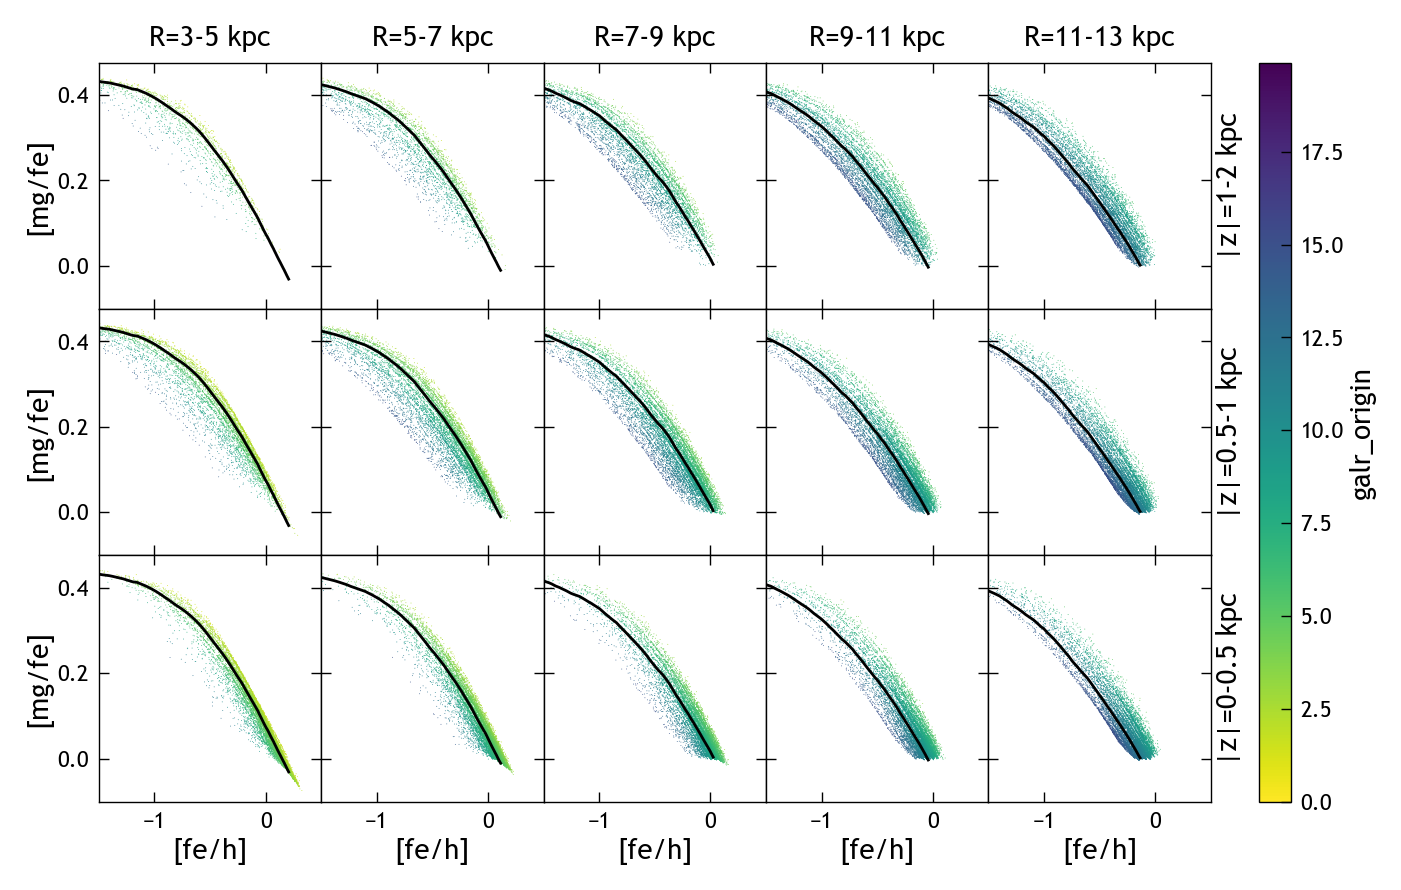

In [4]:
hayden_plot(mzs, '[fe/h]', '[mg/fe]', xlim=(-1.5, 0.5))

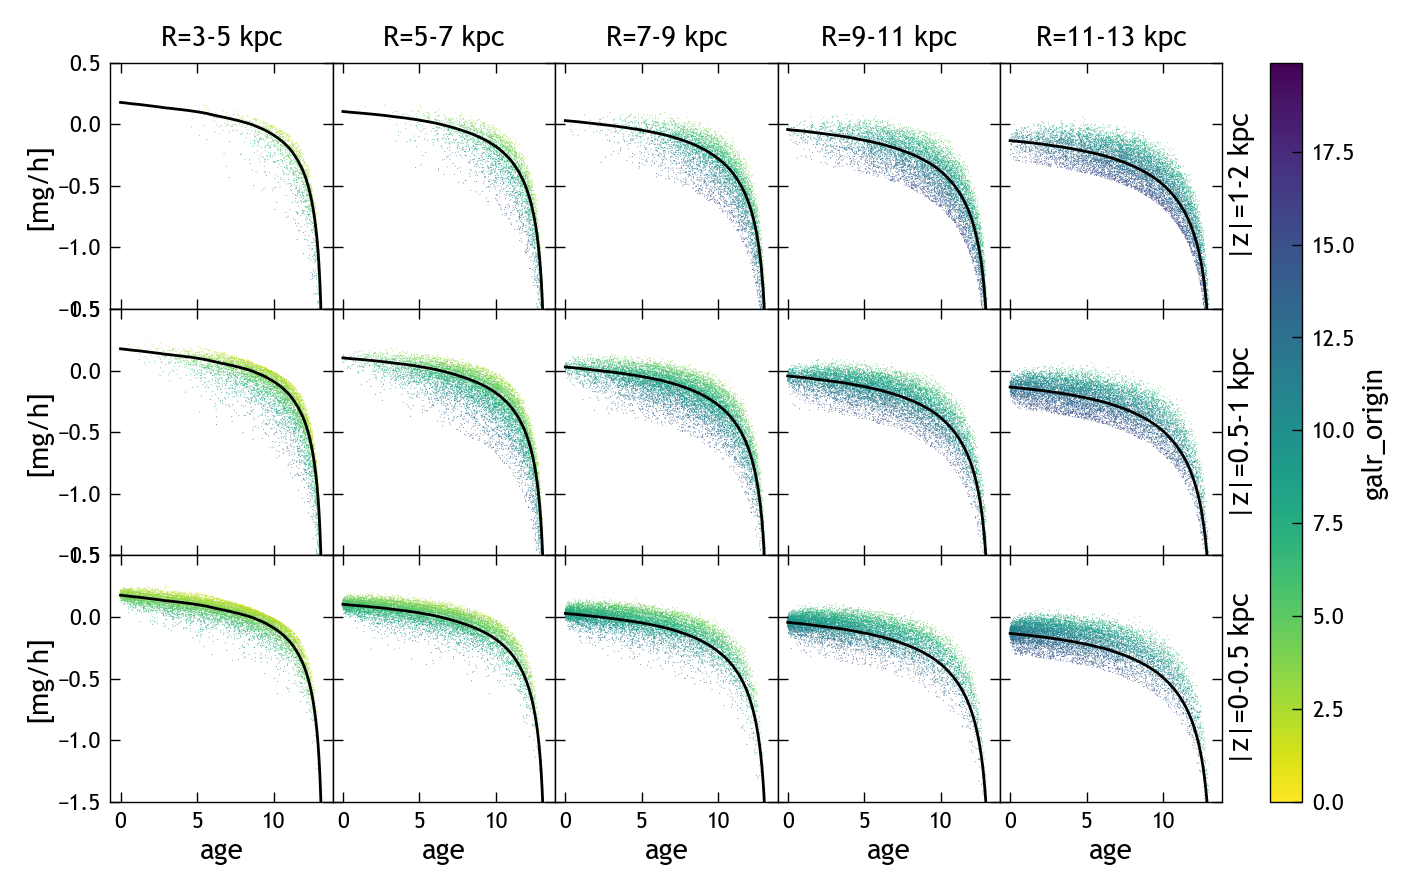

In [5]:
hayden_plot(mzs, 'age', '[mg/h]', ylim=(-1.5, 0.5))

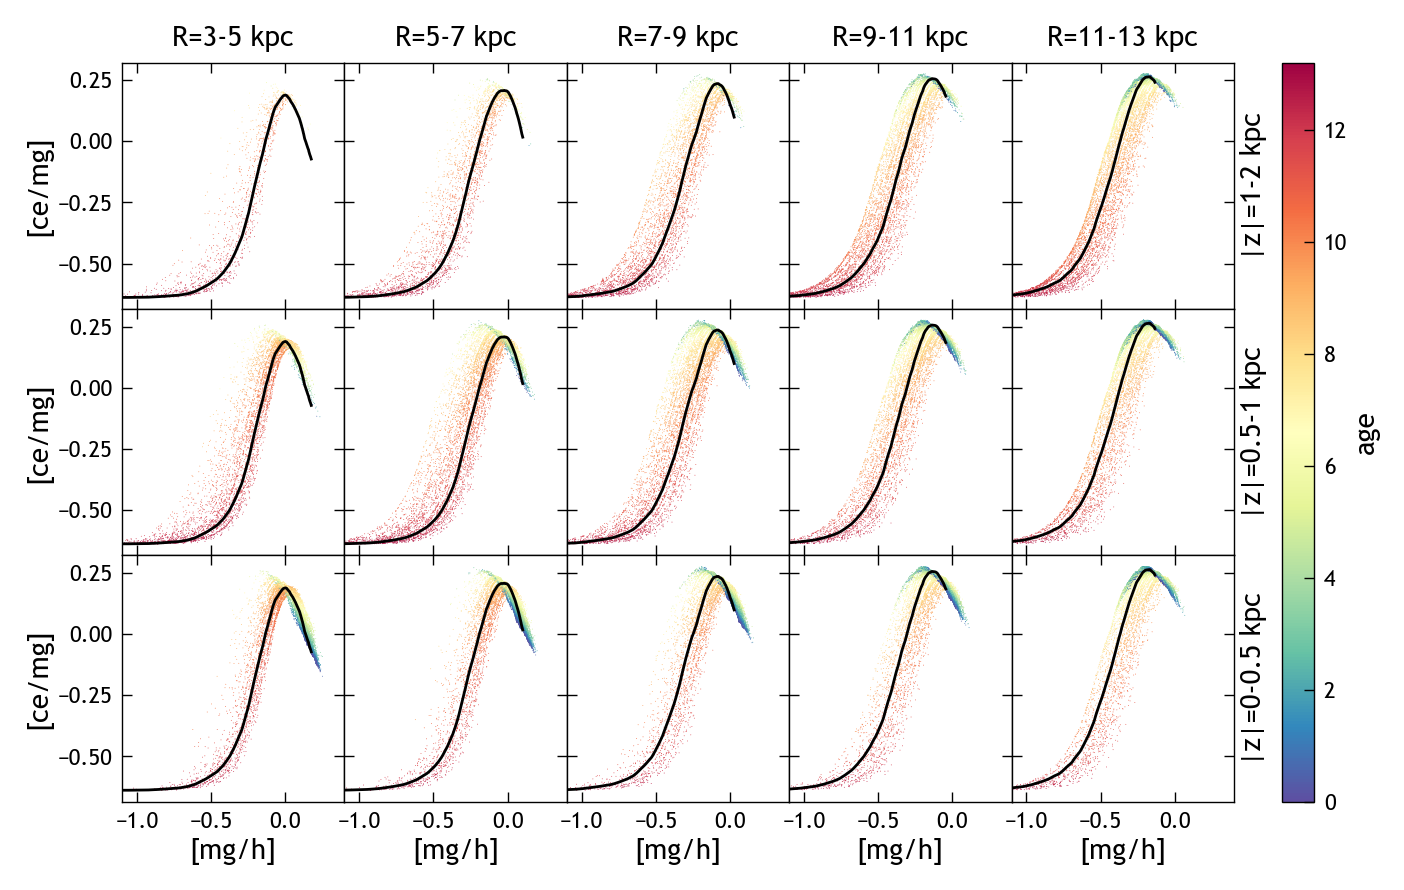

In [6]:
hayden_plot(mzs, '[mg/h]', '[ce/mg]', xlim=(-1.1, 0.4), color_by='age', cmap='Spectral_r')

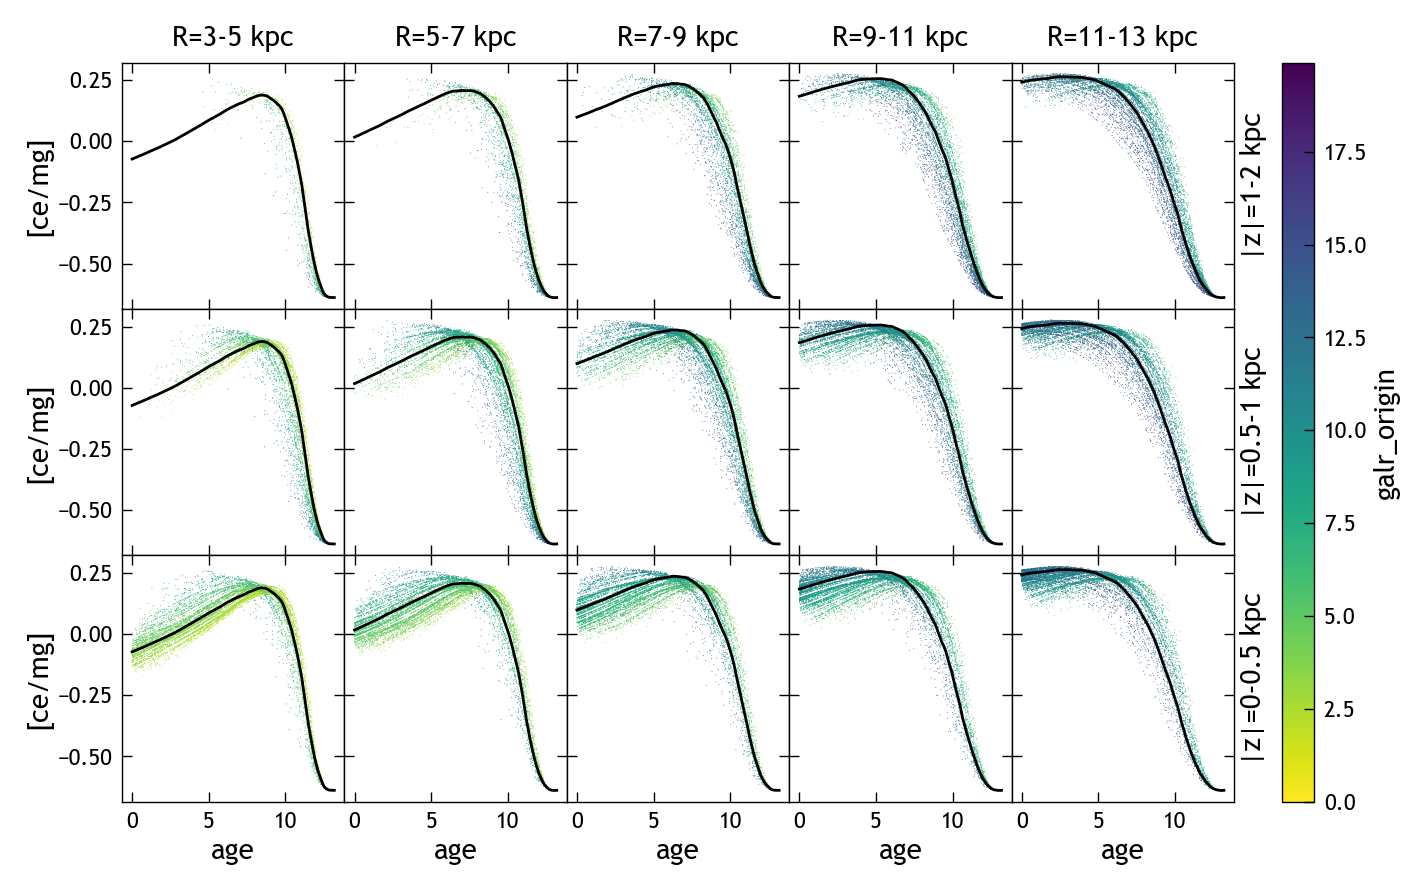

In [7]:
hayden_plot(mzs, 'age', '[ce/mg]')

## Sanity Checks

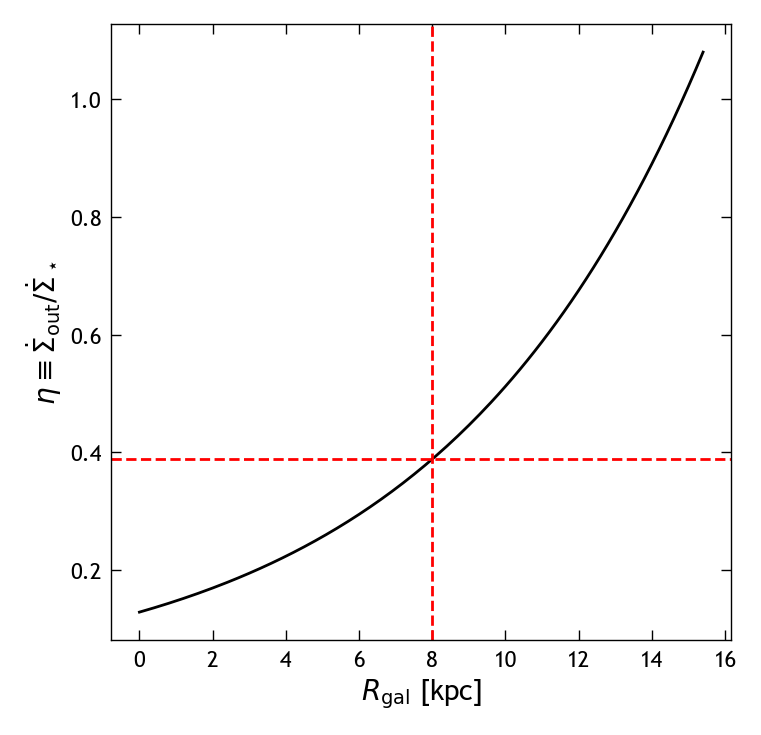

In [9]:
# Plot outflow mass-loading factor
fig, ax = plt.subplots()

multioutput = vice.output(str(paths.multizone / OUTPUT_NAME))
eta_list = radial_gradient(multioutput, 'eta_0')
radii = [i * ZONE_WIDTH for i in range(len(eta_list))]

ax.plot(radii, eta_list, 'k-')

ax.axvline(8, color='r', ls='--')
ax.axhline(eta_list[80], color='r', ls='--')

ax.set_xlabel(r'$R_{\rm gal}$ [kpc]')
ax.set_ylabel(r'$\eta\equiv\dot\Sigma_{\rm out}/\dot\Sigma_\star$')
plt.show()
plt.close()